# Assessment Task 2 - Part A

## EXPERIMENT 3: FASTER-RCNN


# Step 1: Install all relevant dependencies

In [1]:
!pip install torch torchvision -q
!pip install pycocotools lxml tqdm -q

In [2]:
!python --version

Python 3.12.9


In [3]:
!pip install albumentations opencv-python

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached stringzilla-4.6.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (121 kB)
  Using cached simsimd-6.5.16-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (70 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached o

# Step 2: Exploratory Data Analysis

The following section sets up a majority of the imports used across the whole ipynb. Additionally, this section determines key information regarding the Maritime Dataset including:

1. Total classes and their annotated names
2. Dataset class split and its (implied) size
3. Information for determining bounding box sizes

# Step 2(a): Setup Imports and Data Directory Paths

In [4]:
# STEP 3: Imports
import os
import xml.etree.ElementTree as ET
import torch
from torchvision.transforms import functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import box_iou
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random

SEED = 25349642

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [5]:
# Since the metadata.json file does not provide details regarding number of classes or what classes are under 
# the "Aerial_Maritime_Detection" Dataset we must first find out what the classes are. To do this I am going to
# apply it to the Train Dataset given that it houses 70% of the full dataset

annotations_dir = './25349642/Object_Detection/pascal/train'

classes = set()

for file in os.listdir(annotations_dir):
    if file.endswith(".xml"):
        tree = ET.parse(os.path.join(annotations_dir, file))
        root = tree.getroot()

        for obj in root.findall("object"):
            name = obj.find("name").text
            classes.add(name)

print("Classes found:")
print(sorted(classes))
print(f"Total classes: {len(classes)}")

Classes found:
['boat', 'car', 'dock', 'jetski', 'lift']
Total classes: 5


In [6]:
torch.cuda.is_available()

True

In [7]:
# Class list (must match your dataset/annotations for proper index and number of classes)
# faster RCNN needs a background class named `__background__`
CLASSES = ['__background__', 'boat', 'car', 'dock', 'jetski', 'lift']
NUM_CLASSES = len(CLASSES)

In [8]:
TRAIN_DIR = './25349642/Object_Detection/pascal/train'  # Update if different
VAL_DIR = './25349642/Object_Detection/pascal/valid'
TEST_DIR = './25349642/Object_Detection/pascal/test' # putting valid because we do not have a test set - you may have one, if it has annotations, you may evaluate


# Step 2(b): Parse VOC XML Annotations

In [9]:
def parse_voc_xml(xml_file):
    # Parse the XML annotation file using ElementTree
    tree = ET.parse(xml_file)
    root = tree.getroot()

    # Initialize lists to store bounding boxes and labels
    boxes, labels = [], []

    # Loop over all object elements in the XML
    for obj in root.findall("object"):
        # Get the object class name
        label = obj.find("name").text

        # Skip labels that are not in the defined CLASSES list
        if label not in CLASSES:
            continue

        # Convert label name to its corresponding index in CLASSES
        labels.append(CLASSES.index(label))

        # Extract the bounding box coordinates from the XML
        bbox = obj.find("bndbox")
        box = [
            float(bbox.find("xmin").text),  # left
            float(bbox.find("ymin").text),  # top
            float(bbox.find("xmax").text),  # right
            float(bbox.find("ymax").text)   # bottom
        ]
        boxes.append(box)

    # Return list of bounding boxes and their corresponding labels
    return boxes, labels


# Step 2(c): Load Dataset using Custom VOC Dataset

In [10]:
class VOCDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms
        self.images = [f for f in os.listdir(root_dir) if f.endswith('.jpg')]
        self.images.sort()

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root_dir, img_name)
        xml_path = img_path.replace('.jpg', '.xml')

        img = Image.open(img_path).convert("RGB")
        boxes, labels = parse_voc_xml(xml_path)

        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self.images))

        # --- Resize + scale boxes ---
        orig_w, orig_h = img.size
        
        img = F.resize(img, (800, 800))
        
        scale_x = 800 / orig_w
        scale_y = 800 / orig_h
        
        boxes = [
            [
                x1 * scale_x,
                y1 * scale_y,
                x2 * scale_x,
                y2 * scale_y
            ]
            for (x1, y1, x2, y2) in boxes
        ]

        if self.transforms:
            augmented = self.transforms(
                image=np.array(img),
                bboxes=boxes,
                labels=labels
            )

            img = augmented["image"]
            boxes = torch.tensor(augmented["bboxes"], dtype=torch.float32)
            labels = torch.tensor(augmented["labels"], dtype=torch.int64)

        else:
            img = F.to_tensor(img)

            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self.images))

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        return img, target

    def __len__(self):
        return len(self.images)

# Step 2(d): Download a trainable pre-trained model

In [11]:
from torchvision.models.detection.rpn import AnchorGenerator

def get_model(num_classes, backbone="resnet50"):

    anchor_generator = AnchorGenerator(
        sizes=((32,), (64,), (128,), (192,), (256,)),
        aspect_ratios=((0.5, 0.75, 1.0, 1.5, 3.0),) * 5
    )

    if backbone == "resnet50":
        model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
            weights=None,
            rpn_anchor_generator=anchor_generator
        )
    elif backbone == "mobilenet":
        model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
            weights="DEFAULT",
            rpn_anchor_generator=anchor_generator
        )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    model.rpn.nms_thresh = 0.8
    model.rpn.post_nms_top_n_train = 2000
    model.rpn.post_nms_top_n_test = 1000
    model.rpn.pre_nms_top_n_train = 2000
    model.rpn.pre_nms_top_n_test = 1000

    return model

In [12]:
def get_train_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.1),

        A.LongestMaxSize(800),
        A.PadIfNeeded(800, 800),

        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),

        ToTensorV2()
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels'],
        min_visibility=0.3,
        clip=True
    ))

In [13]:
# Create the training dataset
dataset = VOCDataset(
    TRAIN_DIR,
    transforms=get_train_transforms()
)

In [14]:
img, target = dataset[0]
print(img.shape)

torch.Size([3, 800, 800])


# Step 2(e): Dataset Exploration

In [15]:
from collections import Counter

counts = Counter()

for _, target in dataset:
    counts.update(target["labels"].tolist())

print(counts)

Counter({3: 1890, 5: 1829, 4: 435, 2: 174, 1: 147})


In [16]:
for _, t in dataset:
    assert (t["boxes"][:,2] > t["boxes"][:,0]).all()
    assert (t["boxes"][:,3] > t["boxes"][:,1]).all()

print("All boxes valid")

All boxes valid


In [17]:
# Create a DataLoader with custom collate function for handling variable-size targets
data_loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

# Set device to GPU if available, otherwise fallback to CPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Load the Faster R-CNN model and move it to the selected device
# model = get_model(NUM_CLASSES, backbone='resnet50').to(device)
model = get_model(NUM_CLASSES, backbone='resnet50').to(device)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


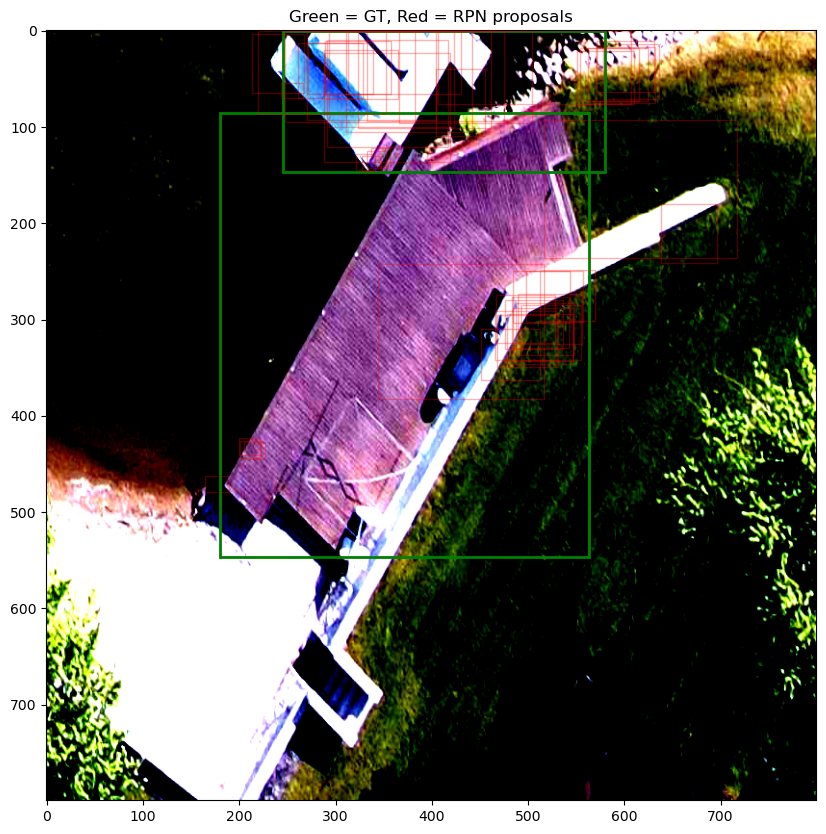

In [18]:
import matplotlib.pyplot as plt

model.eval()

img, target = dataset[0]
img_tensor = img.unsqueeze(0).to(device)

with torch.no_grad():
    images = [img_tensor.squeeze(0)]
    
    # Step 1: convert to ImageList (what Faster R-CNN expects internally)
    images, _ = model.transform(images, None)

    # Step 2: backbone features
    features = model.backbone(images.tensors)

    # Step 3: RPN proposals (THIS is the correct call)
    proposals, _ = model.rpn(images, features, None)

# ---- visualization ----
img_vis = img.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(10,10))
plt.imshow(img_vis)

# GT boxes (green)
for box in target["boxes"]:
    x1, y1, x2, y2 = box
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), x2-x1, y2-y1,
                      edgecolor='green', facecolor='none', linewidth=2)
    )

# RPN proposals (red)
props = proposals[0].cpu()

for i in range(min(50, len(props))):
    x1, y1, x2, y2 = props[i]
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), x2-x1, y2-y1,
                      edgecolor='red', facecolor='none', linewidth=1, alpha=0.3)
    )

plt.title("Green = GT, Red = RPN proposals")
plt.show()

In [19]:
import numpy as np

ws, hs = [], []

for _, target in dataset:
    boxes = target["boxes"]
    w = boxes[:, 2] - boxes[:, 0]
    h = boxes[:, 3] - boxes[:, 1]

    ws.extend(w.tolist())
    hs.extend(h.tolist())

ws = np.array(ws)
hs = np.array(hs)

In [20]:
print("width percentiles:", np.percentile(ws, [10, 50, 90]))
print("height percentiles:", np.percentile(hs, [10, 50, 90]))

width percentiles: [ 55.         140.00001526 233.59999084]
height percentiles: [ 61.33332214 188.         332.        ]


In [21]:
areas = ws * hs

sizes = np.sqrt(np.percentile(areas, [10, 25, 50, 75, 90]))
print(sizes)

[ 66.33251275 100.71742626 154.72557592 197.16659241 235.21903699]


In [22]:
anchor_sizes = tuple((int(s),) for s in sizes[:5])

In [23]:
ratios = ws / (hs + 1e-6)

print(np.percentile(ratios, [10, 25, 50, 75, 90]))

[0.30612242 0.47879461 0.72983848 1.20796449 2.23750028]


# Step 3: Utility for saving a trained model

In [24]:
import torch

def save_model(model, optimizer, epoch, filename="checkpoint.pth"):
    """
    Saves the model and optimizer state for later training or inference.
    Args:
        model (torch.nn.Module): The model to save.
        optimizer (torch.optim.Optimizer): The optimizer used during training.
        epoch (int): Current training epoch.
        filename (str): File name to save the checkpoint.
    """
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, filename)
    print(f"✅ Saved model checkpoint to: {filename}")


# Step 4: Define Evaluation Utilities

In [25]:
def evaluate_map(model, dataset, iou_thresholds=[0.5, 0.75]):
    # Set model to evaluation mode
    model.eval()

    # Lists to store predictions and ground truth for all images
    all_preds, all_targets = [], []

    # Loop over all images in the dataset
    for img, target in dataset:
        # Add batch dimension and move image to device
        img = img.to(device).unsqueeze(0)

        # Run inference without gradients
        with torch.no_grad():
            pred = model(img)[0]

        # Filter out predictions with low confidence scores
        keep = pred['scores'] > 0.3
        pred_boxes = pred['boxes'][keep].cpu()
        pred_labels = pred['labels'][keep].cpu()
        pred_scores = pred['scores'][keep].cpu()

        # Store filtered predictions
        all_preds.append({
            'boxes': pred_boxes,
            'labels': pred_labels,
            'scores': pred_scores
        })

        # Store ground truth (converted to CPU)
        all_targets.append({
            'boxes': target['boxes'].cpu(),
            'labels': target['labels'].cpu()
        })

    # Compute mAP and AR metrics using predictions and targets
    return compute_map_ar(all_preds, all_targets)


# Step 5: Define Metric Computation (per COCO style)

In [26]:
def compute_map_ar(preds, targets, num_classes=len(CLASSES)-1):
    # Initialize the results dictionary with default values
    results = {
        'map': 0, 'map_50': 0, 'map_75': 0,
        'map_per_class': torch.zeros(num_classes),
        'mar_1': 0, 'mar_10': 0, 'mar_100': 0,
        'mar_100_per_class': torch.zeros(num_classes),
    }

    # Lists to hold AP and AR values for each class
    aps = [[] for _ in range(num_classes)]
    ars = [[] for _ in range(num_classes)]

    # Loop through each image's predictions and targets
    for pred, target in zip(preds, targets):
        # Loop through each class (excluding background)
        for class_idx in range(1, num_classes+1):
            # Filter boxes by current class
            gt_mask = target['labels'] == class_idx
            pred_mask = pred['labels'] == class_idx

            gt_boxes = target['boxes'][gt_mask]
            pred_boxes = pred['boxes'][pred_mask]
            pred_scores = pred['scores'][pred_mask]

            # Skip if no GT or predictions
            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue

            # Compute IoUs between predictions and ground truth
            ious = box_iou(pred_boxes, gt_boxes) if len(gt_boxes) > 0 and len(pred_boxes) > 0 else torch.zeros((0, 0))

            # Initialize true positives (TP) and matched GT indices
            tp = torch.zeros(len(pred_boxes))
            matched = set()

            # Match predictions to ground truth based on IoU > 0.5
            for i, row in enumerate(ious):
                max_iou, max_j = torch.max(row, dim=0)
                if max_iou > 0.5 and max_j.item() not in matched:
                    tp[i] = 1
                    matched.add(max_j.item())

            # Compute false positives (FP)
            fp = 1 - tp

            # Cumulative TP and FP for precision-recall curve
            cum_tp = torch.cumsum(tp, dim=0)
            cum_fp = torch.cumsum(fp, dim=0)

            # Compute recall and precision
            recalls = cum_tp / (len(gt_boxes) + 1e-6)
            precisions = cum_tp / (cum_tp + cum_fp + 1e-6)

            # Compute AP (area under precision-recall curve)
            ap = torch.trapz(precisions, recalls) if recalls.numel() > 0 else torch.tensor(0.)
            # AR is the max recall value
            ar = recalls[-1] if recalls.numel() > 0 else torch.tensor(0.)

            # Store per-class AP and AR
            aps[class_idx-1].append(ap.item())
            ars[class_idx-1].append(ar.item())

    # Compute average AP and AR for each class
    ap_avg = torch.tensor([np.mean(cls_ap) if cls_ap else 0. for cls_ap in aps])
    ar_avg = torch.tensor([np.mean(cls_ar) if cls_ar else 0. for cls_ar in ars])

    # Save results
    results['map_per_class'] = ap_avg
    results['mar_100_per_class'] = ar_avg
    results['map'] = ap_avg.mean()
    results['map_50'] = ap_avg.mean()
    results['map_75'] = ap_avg.mean()
    results['mar_100'] = ar_avg.mean()
    results['mar_10'] = ar_avg.mean()
    results['mar_1'] = ar_avg.mean()

    return results


# Step 6: Define Object Detection Transforms

In [27]:
def get_val_transforms():
    return A.Compose([
        A.LongestMaxSize(800),
        A.PadIfNeeded(800, 800),

        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),

        ToTensorV2()
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels']
    ))

# Step 7: Model Training 

# Step 7(a): Optimizer, Epochs and Logging Setup

In [28]:
# Define the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Number of epochs to train
num_epochs = 300  # Increase this if you do not get accuracy

start_epoch = 0 # this is changed if you load a pre-trained model or checkpoint to continue training

# Logging and checkpointing settings
# Depending on the batch size and number of images in training set as num_iterations = num_images/batch_size
# Our batch size is 2, num_images in train = 16, so num_iter = 8, and we can see this in the result output with print_every = 1.
print_every = 1        # Print loss every N batches
save_every = 1         # Save model every N epochs
val_every = 1          # Validate every N epochs
save_dir = './RCNN_training/'
os.makedirs(save_dir, exist_ok=True)

# Initialize logging lists
epoch_losses = []
iteration_losses = []
val_maps = []

val_dataset = VOCDataset(
    VAL_DIR,
    transforms=get_val_transforms()
) # setup val data loader for validation


In [29]:
img, target = dataset[0]

print("Image shape:", img.shape)
print("Boxes:", target["boxes"])

Image shape: torch.Size([3, 800, 800])
Boxes: tensor([[220.0000,   0.0000, 555.0000, 146.6667],
        [236.5000,  85.3333, 620.5000, 546.6667]])


# Step 7(b): EarlyStopping Setup

In [30]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0, window_size=5):
        self.patience = patience
        self.min_delta = min_delta
        self.window_size = window_size

        self.history = []
        self.best_score = None
        self.counter = 0
        self.best_model_path = "best_model.pth"

    def step(self, score, model, optimizer, epoch):
        self.history.append(score)

        if len(self.history) < self.window_size:
            if self.best_score is None or score > self.best_score:
                self.best_score = score
                self.save_checkpoint(model, optimizer, epoch, score)
            return False

        smoothed_score = np.mean(self.history[-self.window_size:])

        if self.best_score is None or smoothed_score > self.best_score + self.min_delta:
            self.best_score = smoothed_score
            self.counter = 0
            self.save_checkpoint(model, optimizer, epoch, smoothed_score)
        else:
            self.counter += 1
            print(f"EarlyStopping {self.counter}/{self.patience} (mAP: {smoothed_score:.4f})")

            if self.counter >= self.patience:
                print("Early stopping triggered.")
                return True

        return False

    def save_checkpoint(self, model, optimizer, epoch, score):
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_score": score
        }, self.best_model_path)

In [31]:
early_stopping = EarlyStopping(patience=15, min_delta=0.001, window_size=3)

# Step 7(c): Training Loop 

Please note for the training loop the epochs trained is longer than the printed terminal contents suggests. This discrepency was caused by the logout timer.

In [ ]:
for epoch in range(start_epoch, num_epochs):
    model.train()  # Set model to training mode
    total_loss = 0  # Track total loss for the epoch

    for i, (images, targets) in enumerate(data_loader):
        # Move all images and targets to the selected device
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Get the loss dict from the model
        loss_dict = model(images, targets)

        cls_weight = 1.5
        loss_dict['loss_classifier'] *= cls_weight

        # Combine all losses into a single scalar
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass and optimizer step
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0) 
        optimizer.step()

        # Accumulate batch loss and append to losses per iteration
        total_loss += losses.item()
        iteration_losses.append(losses.item())
        # Print batch loss every few iterations
        if (i + 1) % print_every == 0:
            print(f"  [Epoch {epoch+1}, Iter {i+1}] Loss: {losses.item():.4f}")

    # Print total loss at the end of the epoch and store losses for loss curve
    print(f"Epoch [{epoch+1}/{num_epochs}], Total Loss: {total_loss:.4f}")
    epoch_losses.append(total_loss)

    scheduler.step()

    if (epoch+1) % val_every == 0:
      # Evaluate on validation set
      val_results = evaluate_map(model, val_dataset)
      val_map = val_results["map"].item()
      val_maps.append(val_map)
      print(f"📈 Validation mAP at epoch {epoch+1}: {val_map:.4f}")

      stop = early_stopping.step(val_map, model, optimizer, epoch+1)

      if stop:
          break

    # Save checkpoint for loss every few epochs
    if (epoch + 1) % save_every == 0:
      save_model(model, optimizer, epoch+1, filename=str(os.path.join(save_dir, f"checkpoint_fasterRcnn_epoch_{epoch+1}.pth")))

# save final model after training is complete
save_model(model, optimizer, epoch+1, filename=str(os.path.join(save_dir,f"final_model_fasterRcnn_epoch_{epoch+1}.pth")))


  [Epoch 1, Iter 1] Loss: 3.5660
  [Epoch 1, Iter 2] Loss: 2.4378
  [Epoch 1, Iter 3] Loss: 1.5046
  [Epoch 1, Iter 4] Loss: 0.9194
  [Epoch 1, Iter 5] Loss: 0.6688
  [Epoch 1, Iter 6] Loss: 1.0521
  [Epoch 1, Iter 7] Loss: 1.8334
  [Epoch 1, Iter 8] Loss: 1.6167
  [Epoch 1, Iter 9] Loss: 1.4005
  [Epoch 1, Iter 10] Loss: 2.6438
  [Epoch 1, Iter 11] Loss: 1.1773
  [Epoch 1, Iter 12] Loss: 1.0297
  [Epoch 1, Iter 13] Loss: 1.3578
  [Epoch 1, Iter 14] Loss: 0.8041
  [Epoch 1, Iter 15] Loss: 1.3808
  [Epoch 1, Iter 16] Loss: 1.4492
  [Epoch 1, Iter 17] Loss: 2.4939
  [Epoch 1, Iter 18] Loss: 2.7183
  [Epoch 1, Iter 19] Loss: 1.4952
  [Epoch 1, Iter 20] Loss: 1.4821
  [Epoch 1, Iter 21] Loss: 0.8715
  [Epoch 1, Iter 22] Loss: 0.8300
  [Epoch 1, Iter 23] Loss: 1.0255
  [Epoch 1, Iter 24] Loss: 0.7324
  [Epoch 1, Iter 25] Loss: 0.9434
  [Epoch 1, Iter 26] Loss: 2.2196
  [Epoch 1, Iter 27] Loss: 1.1356
  [Epoch 1, Iter 28] Loss: 1.8381
  [Epoch 1, Iter 29] Loss: 0.9834
  [Epoch 1, Iter 30] Lo

# Step 7(d): Validation mAP Scores per Epoch 

Just like the training loop, the figures for the Validation mAP Scores and Loss Curves could not be plotted due to the logout timer. Below is the recovery and visualisation for the Validation mAP scores.

In [35]:
import os
import torch
import matplotlib.pyplot as plt
import re

checkpoint_dir = "./RCNN_training"

checkpoint_files = [
    f for f in os.listdir(checkpoint_dir)
    if f.endswith(".pth") and "epoch" in f
]

checkpoint_files = sorted(
    checkpoint_files,
    key=lambda x: int(re.findall(r"epoch_(\d+)", x)[0])
)

epochs = []
val_maps = []

for ckpt in checkpoint_files:

    if not ckpt.endswith(".pth"):
        continue

    print(f"Evaluating {ckpt}")

    # rebuild model
    model = get_model(NUM_CLASSES, backbone='resnet50').to(device)

    checkpoint = torch.load(
        os.path.join(checkpoint_dir, ckpt),
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(checkpoint["model_state_dict"])

    model.eval()

    # evaluate
    results = evaluate_map(model, val_dataset)

    val_map = results["map"].item()

    # epoch number
    epoch = checkpoint["epoch"]

    epochs.append(epoch)
    val_maps.append(val_map)

    print(f"Epoch {epoch}: mAP={val_map:.4f}")

Evaluating checkpoint_fasterRcnn_epoch_1.pth
Epoch 1: mAP=0.0476
Evaluating checkpoint_fasterRcnn_epoch_2.pth
Epoch 2: mAP=0.0687
Evaluating checkpoint_fasterRcnn_epoch_3.pth
Epoch 3: mAP=0.0794
Evaluating checkpoint_fasterRcnn_epoch_4.pth
Epoch 4: mAP=0.0833
Evaluating checkpoint_fasterRcnn_epoch_5.pth
Epoch 5: mAP=0.0935
Evaluating checkpoint_fasterRcnn_epoch_6.pth
Epoch 6: mAP=0.1149
Evaluating checkpoint_fasterRcnn_epoch_7.pth
Epoch 7: mAP=0.1054
Evaluating checkpoint_fasterRcnn_epoch_8.pth
Epoch 8: mAP=0.1149
Evaluating checkpoint_fasterRcnn_epoch_9.pth
Epoch 9: mAP=0.1243
Evaluating checkpoint_fasterRcnn_epoch_10.pth
Epoch 10: mAP=0.1294
Evaluating checkpoint_fasterRcnn_epoch_11.pth
Epoch 11: mAP=0.1388
Evaluating checkpoint_fasterRcnn_epoch_12.pth
Epoch 12: mAP=0.1392
Evaluating checkpoint_fasterRcnn_epoch_13.pth
Epoch 13: mAP=0.1472
Evaluating checkpoint_fasterRcnn_epoch_14.pth
Epoch 14: mAP=0.1464
Evaluating checkpoint_fasterRcnn_epoch_15.pth
Epoch 15: mAP=0.1463
Evaluating ch

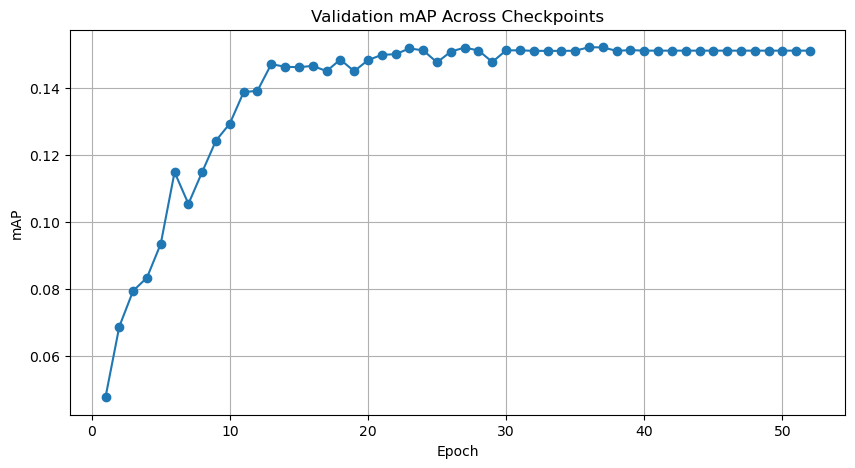

In [36]:
plt.figure(figsize=(10,5))

plt.plot(epochs, val_maps, marker='o')

plt.title("Validation mAP Across Checkpoints")

plt.xlabel("Epoch")
plt.ylabel("mAP")

plt.grid(True)

plt.show()

# Step 7(e): Print model summary

In [31]:
print(model)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

# Step 8: Visualisation of Predictions

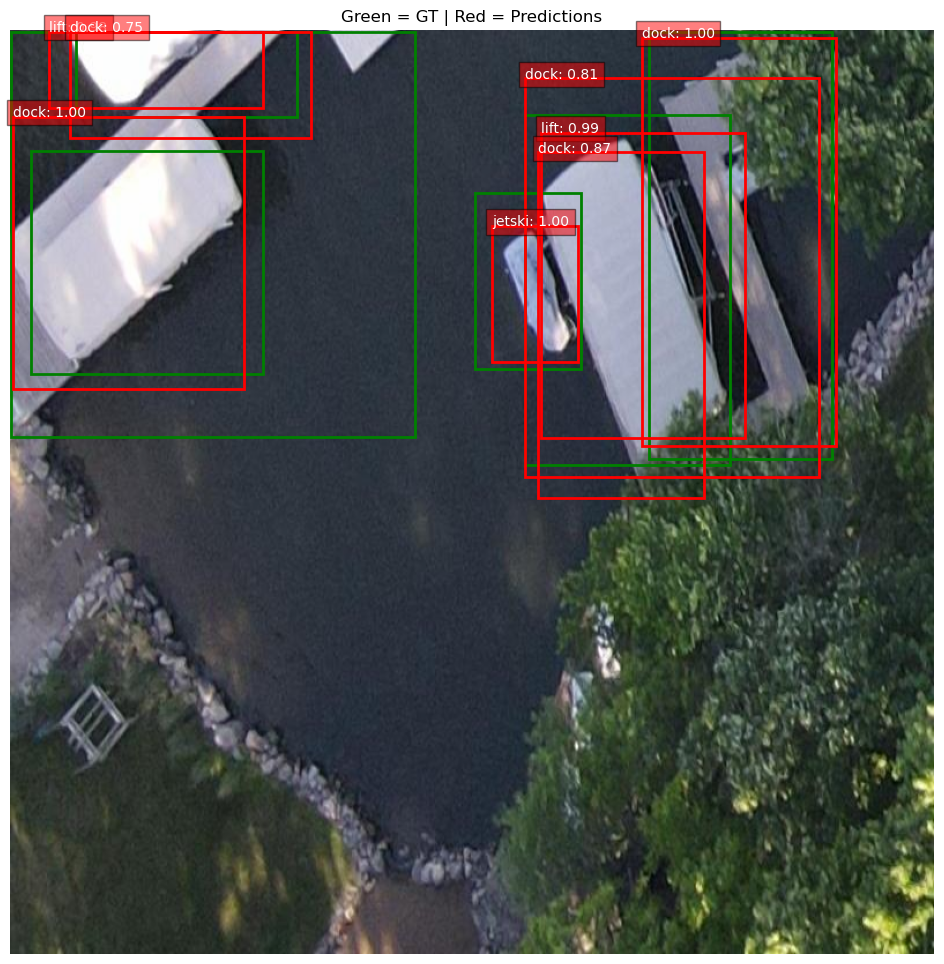

In [40]:
# -----------------------------------
# LOAD BEST MODEL
# -----------------------------------

model = get_model(NUM_CLASSES, backbone='resnet50').to(device)

checkpoint = torch.load(
    "best_model.pth",
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

# -----------------------------------
# VISUALISE PREDICTIONS
# -----------------------------------

img, target = val_dataset[35]

img_tensor = img.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)[0]

# unnormalize image
img_vis = img.permute(1,2,0).cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_vis = (img_vis * std) + mean
img_vis = np.clip(img_vis, 0, 1)

plt.figure(figsize=(12,12))
plt.imshow(img_vis)

ax = plt.gca()

# -------------------------
# GROUND TRUTH (GREEN)
# -------------------------
for box in target["boxes"]:

    x1, y1, x2, y2 = box.cpu().numpy()

    ax.add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            edgecolor='green',
            facecolor='none',
            linewidth=2
        )
    )

# -------------------------
# PREDICTIONS (RED)
# -------------------------
for box, label, score in zip(
    output['boxes'],
    output['labels'],
    output['scores']
):

    if score > 0.5:

        x1, y1, x2, y2 = box.cpu().numpy()

        ax.add_patch(
            plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                edgecolor='red',
                facecolor='none',
                linewidth=2
            )
        )

        ax.text(
            x1,
            y1,
            f"{CLASSES[label]}: {score:.2f}",
            color='white',
            bbox=dict(facecolor='red', alpha=0.5)
        )

plt.title("Green = GT | Red = Predictions")
plt.axis("off")
plt.show()

# Step 9(a)[i]: Evaluation on Train Set

In [41]:
# Evaluate the model on the training dataset
train_results = evaluate_map(model, dataset)

# Print overall mAP/mAR results for the training set
print("📊 Train set mAP/mAR results:")
for k, v in train_results.items():
    # Convert torch tensors to NumPy arrays for clean printing
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.numpy()}")
    else:
        print(f"{k}: {v}")


📊 Train set mAP/mAR results:
map: 0.18095530499949342
map_50: 0.18095530499949342
map_75: 0.18095530499949342
map_per_class: [0.         0.24567588 0.23507431 0.16048371 0.26354263]
mar_1: 0.9597678504454628
mar_10: 0.9597678504454628
mar_100: 0.9597678504454628
mar_100_per_class: [0.95945854 0.96698045 0.97970576 0.92499928 0.96769522]


# Step 9(a)[ii]: Pretty-Print Class AP and AR results

In [42]:
# Print header for per-class AP / AR table
print("\nAP / AR per class\n" + "-"*73)
print(f"| {'ID':<3} | {'Class':<20} | {'AP':<18} | {'AR':<18} |")
print("-"*73)

# Loop through each class (excluding background)
for i, cls in enumerate(CLASSES[1:], 1):
    # Get AP and AR for the current class
    ap = train_results['map_per_class'][i-1].item()
    ar = train_results['mar_100_per_class'][i-1].item()

    # Print formatted row
    print(f"| {i:<3} | {cls:<20} | {ap:<18.3f} | {ar:<18.3f} |")

# Print average AP and AR across all classes
print("-"*73)
print(f"| {'Avg':<24} | {train_results['map'].item():<18.3f} | {train_results['mar_100'].item():<18.3f} |")
print("-"*73)



AP / AR per class
-------------------------------------------------------------------------
| ID  | Class                | AP                 | AR                 |
-------------------------------------------------------------------------
| 1   | boat                 | 0.000              | 0.959              |
| 2   | car                  | 0.246              | 0.967              |
| 3   | dock                 | 0.235              | 0.980              |
| 4   | jetski               | 0.160              | 0.925              |
| 5   | lift                 | 0.264              | 0.968              |
-------------------------------------------------------------------------
| Avg                      | 0.181              | 0.960              |
-------------------------------------------------------------------------


# Step 9(b)[i]: Evaluation on Validation Set

In [43]:
# Create a DataLoader for the validation set
val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,  # No shuffling for evaluation
    collate_fn=lambda x: tuple(zip(*x))  # Custom collate function to handle varying targets
)


In [44]:
# Evaluate the model on the validation dataset
val_results = evaluate_map(model, val_dataset)

# Print overall mAP/mAR results for the validation set
print("\n📊 Validation set mAP/mAR results:")
for k, v in val_results.items():
    # Convert tensors to NumPy arrays for cleaner output
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.numpy()}")
    else:
        print(f"{k}: {v}")



📊 Validation set mAP/mAR results:
map: 0.15216468159588406
map_50: 0.15216468159588406
map_75: 0.15216468159588406
map_per_class: [0.         0.19583318 0.22103438 0.0809178  0.26303805]
mar_1: 0.8671505520862024
mar_10: 0.8671505520862024
mar_100: 0.8671505520862024
mar_100_per_class: [0.79999924 0.94999928 0.92031184 0.74154527 0.92389713]


# Step 9(b)[ii]: Pretty-Print Class AP and AR results

In [45]:
# Print header for per-class AP / AR table on validation set
print("\nAP / AR per class on validation\n" + "-"*73)
print(f"| {'ID':<3} | {'Class':<20} | {'AP':<18} | {'AR':<18} |")
print("-"*73)

# Loop through each class (excluding background)
for i, cls in enumerate(CLASSES[1:], 1):
    # Get per-class AP and AR from results
    ap = val_results['map_per_class'][i-1].item()
    ar = val_results['mar_100_per_class'][i-1].item()

    # Print table row for the class
    print(f"| {i:<3} | {cls:<20} | {ap:<18.3f} | {ar:<18.3f} |")

# Print average AP and AR across all classes
print("-"*73)
print(f"| {'Avg':<24} | {val_results['map'].item():<18.3f} | {val_results['mar_100'].item():<18.3f} |")
print("-"*73)



AP / AR per class on validation
-------------------------------------------------------------------------
| ID  | Class                | AP                 | AR                 |
-------------------------------------------------------------------------
| 1   | boat                 | 0.000              | 0.800              |
| 2   | car                  | 0.196              | 0.950              |
| 3   | dock                 | 0.221              | 0.920              |
| 4   | jetski               | 0.081              | 0.742              |
| 5   | lift                 | 0.263              | 0.924              |
-------------------------------------------------------------------------
| Avg                      | 0.152              | 0.867              |
-------------------------------------------------------------------------


# Step 9(c)[i]: Evaluation on Test Set

In [46]:
# Create the test dataset
test_dataset = VOCDataset(
    TEST_DIR,
    transforms=get_val_transforms()
)

# Create a DataLoader for the test set
test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,  # No shuffling needed for evaluation
    collate_fn=lambda x: tuple(zip(*x))  # Handle varying-size targets
)


In [47]:
# Evaluate the model on the test dataset
test_results = evaluate_map(model, test_dataset)

# Print overall mAP/mAR results for the test set
print("\n📊 Test set mAP/mAR results:")
for k, v in test_results.items():
    # Convert torch tensors to NumPy arrays for cleaner display
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.numpy()}")
    else:
        print(f"{k}: {v}")



📊 Test set mAP/mAR results:
map: 0.16311682459614857
map_50: 0.16311682459614857
map_75: 0.16311682459614857
map_per_class: [0.         0.23660694 0.21728449 0.10784303 0.25384965]
mar_1: 0.8333566341170913
mar_10: 0.8333566341170913
mar_100: 0.8333566341170913
mar_100_per_class: [0.61290264 0.99999928 0.91128141 0.72303864 0.9195612 ]


# Step 9(c)[ii]: Pretty-Print Class AP and AR results

In [48]:
# Print table header for per-class AP and AR
print("\nAP / AR per class on test\n" + "-"*73)
print(f"| {'ID':<3} | {'Class':<20} | {'AP':<18} | {'AR':<18} |")
print("-"*73)

# Loop through each class (excluding background)
for i, cls in enumerate(CLASSES[1:], 1):
    # Get AP and AR for the current class
    ap = test_results['map_per_class'][i-1].item()
    ar = test_results['mar_100_per_class'][i-1].item()

    # Print table row for the class
    print(f"| {i:<3} | {cls:<20} | {ap:<18.3f} | {ar:<18.3f} |")

# Print average AP and AR across all classes
print("-"*73)
print(f"| {'Avg':<24} | {test_results['map'].item():<18.3f} | {test_results['mar_100'].item():<18.3f} |")
print("-"*73)



AP / AR per class on test
-------------------------------------------------------------------------
| ID  | Class                | AP                 | AR                 |
-------------------------------------------------------------------------
| 1   | boat                 | 0.000              | 0.613              |
| 2   | car                  | 0.237              | 1.000              |
| 3   | dock                 | 0.217              | 0.911              |
| 4   | jetski               | 0.108              | 0.723              |
| 5   | lift                 | 0.254              | 0.920              |
-------------------------------------------------------------------------
| Avg                      | 0.163              | 0.833              |
-------------------------------------------------------------------------


# Step 10: Utility to load trained model for future use

In [49]:
def load_model(model, optimizer=None, filename="checkpoint.pth", device="cpu"):
    """
    Loads a model (and optionally optimizer) from a saved checkpoint.
    Args:
        model (torch.nn.Module): The model architecture to load weights into.
        optimizer (optional): The optimizer to load state into (if continuing training).
        filename (str): Path to the saved checkpoint.
        device (str or torch.device): Device to map the model to.
    Returns:
        model, optimizer (if provided), start_epoch
    """
    checkpoint = torch.load(
        filename,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    start_epoch = checkpoint.get('epoch', 0)

    if optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        return model, optimizer, start_epoch

    return model, start_epoch


In [51]:
# Rebuild model architecture
model = get_model(NUM_CLASSES, backbone='resnet50')

# Load the model (without optimizer if you're not training)
model, start_epoch = load_model(
    model,
    filename="best_model.pth",
    device=device
)
# Set to eval mode for inference
model.eval()


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu